# 泰坦尼克号数据分析

> 你的第一个端到端 Pandas 项目。目标：把 NumPy/Pandas 常用 API 在真实数据上走一遍。

## 你将学到什么

| 步骤 | 涉及的核心 API |
|---|---|
| 1. 加载数据 | `seaborn.load_dataset`, `pd.read_csv`, `df.to_csv` |
| 2. 看数据 | `head`, `info`, `describe`, `shape`, `columns`, `dtypes` |
| 3. 检查缺失值 | `isna`, `sum`, `sort_values` |
| 4. 清洗缺失 | `fillna`, `median`, `mode`, `drop` |
| 5. 探索分析 | `groupby`, `value_counts`, 布尔筛选 |
| 6. 可视化 | `seaborn.barplot`, `histplot` |
| 7. 特征工程 | 列运算、`assign`, `astype` |
| 8. 转 NumPy | `to_numpy`, 类别编码 |

## 怎么用这个 Notebook

- 一个 cell 一个 cell 看
- 看不懂的标记下来，问 Claude 解释
- 改改参数、加几行 `print`，体会数据
- **代码不用背**，看明白即可，肌肉记忆在做 PyTorch 时再练


## 0. 导入工具

每个库的作用：
- `pandas` (pd) — 数据分析主力
- `numpy` (np) — 底层数值计算
- `seaborn` (sns) — 美观的统计图表 + 内置数据集
- `matplotlib.pyplot` (plt) — 底层绘图引擎


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 让 pandas 显示更多列、更宽，方便看
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

# 图表风格
sns.set_style('whitegrid')
sns.set_palette('Set2')

# 中文字体（macOS 默认有 PingFang，能显示中文标题）
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False


## 1. 加载数据

策略：**seaborn 自带 titanic 数据集**，第一次会自动联网下载到 `~/seaborn-data/`，之后离线也能用。同时保存一份本地副本，更稳。

> `data/` 文件夹已经在 `.gitignore` 里，不会污染 git。


In [ ]:
df = sns.load_dataset('titanic')

# 保存一份本地副本
os.makedirs('data', exist_ok=True)
df.to_csv('data/titanic.csv', index=False)

print(f'成功加载 {len(df)} 行 × {df.shape[1]} 列数据')
print(f'本地备份已保存到 data/titanic.csv')


成功加载 891 行 × 15 列数据
本地备份已保存到 data/titanic.csv


## 2. 第一眼看数据

拿到任何数据集，**固定先做这几件事**：

1. `head()` 看前几行长啥样
2. `shape` / `columns` 知道规模和字段
3. `info()` 看每列类型 + 有没有缺失
4. `describe()` 看数值列的分布

这套动作我建议**每次新数据集都跑一遍**，30 秒钟，但能让你心里有数。


In [37]:
# 看前 5 行
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size,is_alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,1


In [ ]:
print(f'形状: {df.shape}   （{df.shape[0]} 行 × {df.shape[1]} 列）')
print(f'\n列名: {list(df.columns)}')
print(f'\n每列类型:')
print(df.dtypes)


In [ ]:
# info() 一次性告诉你：列数、行数、每列类型、每列非空数量
df.info()


In [ ]:
# describe() 只统计数值列；分类列（sex / class 等）不会出现
df.describe()


## 3. 检查缺失值

**真实数据永远是脏的**。检查方法：

- `isna()` 返回每个格子是否为 NaN 的布尔表
- `.sum()` 按列求和（True 算 1）→ 得到每列的缺失个数


In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
result = pd.DataFrame({'缺失数': missing, '缺失比例(%)': missing_pct})
print(result)


## 4. 清洗缺失值

策略（实战里通常这么决定）：

| 列 | 缺失率 | 策略 | 理由 |
|---|---|---|---|
| `deck` | 77% | **直接弃用** | 缺太多，硬填会扭曲分布 |
| `age` | 20% | **用中位数填** | 中位数对异常值不敏感 |
| `embarked` / `embark_town` | < 1% | **用众数填** | 缺得少，用最常见值兜底 |

> **没有"标准答案"**——清洗策略取决于业务理解。这里是常规做法。


In [ ]:
# 1) 弃用 deck 列
df = df.drop(columns=['deck'])

# 2) age 用中位数填
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)
print(f'age 缺失用中位数 {median_age} 填补完成')

# 3) embarked / embark_town 用众数填
mode_embarked = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(mode_embarked)
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
print(f'embarked 缺失用众数 "{mode_embarked}" 填补完成')

# 验证一下
print(f'\n清洗后还有缺失的列:')
remaining = df.isna().sum()
print(remaining[remaining > 0] if (remaining > 0).any() else '已无缺失 ✓')


## 5. 探索性分析（Pandas 的灵魂在这里）

`groupby` 三步走：**拆分 → 应用 → 合并**——把表按某列拆成多组，每组算个数，再拼回来。

下面挖几个故事：
- 性别 vs 存活率
- 船舱等级 vs 存活率
- 性别 × 等级 双重交叉
- 登船港口的分布


### 拆解 `df.groupby('sex')['survived'].mean()`

这是一个**三步链式调用**，每一步都返回一个对象给下一步继续操作。先把它拆开跑一遍，再看完整版。

```
df.groupby('sex')         ['survived']            .mean()
   ↓                          ↓                      ↓
按 sex 列把行分组      每组只看 survived 这列     每组算平均值
```

**iOS / Swift 类比**：

```swift
passengers
    .grouped(by: \.sex)          // groupby('sex')
    .mapValues { $0.map(\.survived) }   // ['survived']
    .mapValues { $0.average }            // .mean()
```

**SQL 类比**：

```sql
SELECT sex, AVG(survived) FROM passengers GROUP BY sex;
```

Pandas 用 3 个 token 表达 SQL 一整行的意思——这就是它的威力。


In [ ]:
# 【第一步】df.groupby('sex')
# 这一步只是把表按 sex 列"分堆"，还没算任何东西
# 返回的是 DataFrameGroupBy 对象 —— "已分组但还没聚合"的中间状态

g = df.groupby('sex')
print('类型:', type(g).__name__)
print('分了几组:', g.ngroups)
print('组的名字:', list(g.groups.keys()))
print('\n每组的行数:')
print(g.size())


In [ ]:
# 【第二步】df.groupby('sex')['survived']
# 在分好组的基础上，只挑出 survived 这一列
# 返回 SeriesGroupBy 对象 —— "已分组的某一列"

g_survived = df.groupby('sex')['survived']
print('类型:', type(g_survived).__name__)

# 看看每组的 survived 列长啥样（只取前 8 个）
for name, sub_series in g_survived:
    print(f'\n{name} 组的 survived (前8个): {list(sub_series.head(8))}')


In [12]:
# 【第三步】.mean() —— 对每组的 survived 求平均
# 因为 survived 是 0/1（活/没活），平均值就 = 存活率
# 这才是我们要的最终答案

result = df.groupby('sex')['survived'].mean()
print('类型:', type(result).__name__, '  ← 注意：现在是普通的 Series 了，不再是 GroupBy 对象')
print('\n性别 vs 存活率:')
print(result)


**总结一下"链式调用"在干嘛**：

| 表达式 | 返回类型 | 在做啥 |
|---|---|---|
| `df` | DataFrame | 原始表 |
| `df.groupby('sex')` | DataFrameGroupBy | 把表按 sex 列分堆（**还没算**） |
| `df.groupby('sex')['survived']` | SeriesGroupBy | 每堆里只看 survived 列 |
| `df.groupby('sex')['survived'].mean()` | Series | 对每堆的 survived 求平均 ← 最终结果 |

**关键观念**：`.groupby()` 是 **lazy（懒）** 的——它只是"打了个标签说要分组"，不会立即计算。直到你调用聚合函数（`.mean()` / `.sum()` / `.count()` 等），它才真正动手算。

这跟 Swift 的 `lazy` 序列、SQL 的 query optimizer 一个道理——延迟执行直到必要时刻。

下面这个 cell 就是上面三步的**合并简洁版**——你看完上面的拆解，下面这行的含义就一目了然了：


### 进阶认知：`groupby()` 是一个"承诺"，不是真的把表拆开

刚才你看到 `df.groupby('sex')` 返回的不是"两个小 DataFrame"，而是一个叫 **DataFrameGroupBy** 的对象。这背后是个重要的设计哲学：

> **`.groupby()` 只是"承诺能给你每组的数据"，但它不会立刻去拆。直到你调用聚合方法（`.mean()` / `.sum()` / 遍历 / `get_group()`）时，才会按需现做。**

#### 直觉版 vs 精确版

| 直觉理解（够用） | 精确理解 |
|---|---|
| `groupby` 把表拆成多个小 DataFrame | `groupby` 只是"打了组标签"，记住"哪些行属于哪组"的映射 |
| 之后的 `.mean()` 是在这些小表上算 | `.mean()` 直接在原表上按标签算，**根本没真的拆** |

#### 为什么这么设计

立刻拆 → 占内存 + 慢；懒拆 → 0 额外开销 + 灵活。

| 立刻拆成 N 份 | 懒包装（实际方案） |
|---|---|
| 立刻分配 N 份内存 | 0 额外内存，只记"行号 → 组名"的映射 |
| 拆完发现你只是 `.mean()` —— 白拆 | 直接在原数据上算，跳过拆 |
| 100 万行 × 100 组 → 极慢 | 100 万行 × 100 组 → 极快 |

#### 你已经见过的"懒/承诺"模式（类比）

- **Swift**: `array.lazy.filter { ... }` —— 不立刻过滤，只是打标签，遍历时才算
- **SQL**: `GROUP BY` —— 数据库引擎不会真的拆表，只是构建查询计划，执行时一次算完
- **iOS RxSwift/Combine**: `Publisher` —— 一条订阅链建好不会立刻执行，有 subscriber 才开始流

Pandas GroupBy 是同一思路。**先建好"想做什么"的描述，到必要时刻一气呵成执行**，比"一步一步实打实地动数据"快得多。

#### 真要拿到"拆开的 DataFrame 们"也能

```python
# 方式 1：遍历，每次现做一个子 DataFrame
for name, sub_df in df.groupby('sex'):
    print(name, sub_df.shape)

# 方式 2：取指定一组
female_df = df.groupby('sex').get_group('female')   # 真的是个 DataFrame

# 方式 3：转成 dict（{组名: 子DataFrame}）
groups = dict(list(df.groupby('sex')))
groups['female'].head()
```

但**实战中你 90% 的场景不需要真的拿到子表**——你直接在 GroupBy 对象上调聚合就行，让 Pandas 内部处理。这才是 Pandas 快的秘密。

---

**带着这个观念再看下面这一行原版代码——它现在不再神秘了**：


In [ ]:
# 按性别分组，算每组的存活率
survival_by_sex = df.groupby('sex')['survived'].mean()
print('性别 vs 存活率:')
print(survival_by_sex)
print(f'\n→ 女性存活率是男性的 {survival_by_sex["female"]/survival_by_sex["male"]:.1f} 倍')


性别 vs 存活率:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

→ 女性存活率是男性的 3.9 倍


In [ ]:
# 按船舱等级
survival_by_class = df.groupby('pclass')['survived'].mean()
print('船舱等级 vs 存活率:')
print(survival_by_class)
print('\n→ 头等舱(1) 比 三等舱(3) 存活率高出一倍多')


In [ ]:
# 双重分组：性别 × 船舱等级
# unstack() 把第二层 group 转成列，得到一个漂亮的交叉表
double_group = df.groupby(['sex', 'pclass'])['survived'].mean().unstack()
print('性别 × 船舱等级 的存活率:')
print(double_group.round(2))
print('\n→ 头等舱女性几乎全活（97%），三等舱男性几乎全没（13%）')


In [ ]:
# 各登船港口的分布 + 存活率
print('登船港口分布:')
print(df['embark_town'].value_counts())
print('\n各港口存活率:')
print(df.groupby('embark_town')['survived'].mean().sort_values(ascending=False).round(2))


## 6. 可视化

数字看完，画几张图——人脑对图形比数字敏感得多。

> 如果图表里中文显示成方框，是字体问题。第 0 步那段 `plt.rcParams` 已经处理了 macOS 的字体，理论上能正常显示。


### matplotlib 30 秒速通（看懂下面代码够用）

> 课程 day05 会专门讲 matplotlib（`P03_Show.ipynb` + `P05_SeaBorn.ipynb`），这里先给最小够用版让你看懂当前代码。

#### 1. 它是底层画图引擎，seaborn 站在它肩膀上

```
你的图表
   ↑
seaborn      sns.barplot / histplot ...      ← 更美观、更简洁，但不灵活
   ↑
matplotlib   plt.bar / plt.hist ...           ← 底层、什么都能干、API 啰嗦
```

实战用法：**seaborn 画主体（一行搞定），matplotlib 调细节（标题、布局、子图）**。这就是为什么 notebook 里两个一起 import。

#### 2. 两个核心概念：Figure 和 Axes

```
┌─────────────────────────────────────┐
│  Figure（画布，整张大图）             │
│  ┌─────────────┐  ┌─────────────┐   │
│  │  Axes 0     │  │  Axes 1     │   │   ← 一个 Figure 可以装多个 Axes
│  │ (子图1)     │  │ (子图2)     │   │
│  └─────────────┘  └─────────────┘   │
└─────────────────────────────────────┘
```

- **Figure** = 整张画布（最终输出的一张图片）
- **Axes** = 画布上的一个具体子图（含坐标轴）。注意单数 `Axes` 也是这个名字，不是复数。

#### 3. 必须认识的 5 个函数

| 函数 | 作用 |
|---|---|
| `plt.subplots(rows, cols, figsize=(w,h))` | 创建 Figure 和 Axes 网格，返回 `(fig, axes)` |
| `ax.plot / bar / hist / scatter / ...` | 在某个 Axes 上画图 |
| `ax.set_title / set_xlabel / set_ylabel` | 子图标题和坐标轴标签 |
| `plt.tight_layout()` | 自动调整子图间距，避免重叠 |
| `plt.show()` | 显示（Jupyter 里通常自动显示，写不写都行） |

#### 4. 两种 API 风格——你会同时见到，别懵

| 风格 | 写法 | 何时用 |
|---|---|---|
| **状态机风格**（旧） | `plt.title(...)`, `plt.plot(...)` | 快画单张图，新手友好 |
| **面向对象风格**（新，推荐） | `ax.set_title(...)`, `ax.plot(...)` | 多子图、复杂控制 |

**关键差异**：
- `plt.xxx(...)` → 作用于"当前活动 Axes"（隐式）
- `ax.xxx(...)` → 作用于"你指定的 Axes"（显式）

**iOS 类比**：
- `plt` 风格 ≈ UIKit 全局函数偷偷作用于全局上下文
- `ax` 风格 ≈ SwiftUI 显式 `view.modifier(...)`，明确说改谁

后者更易维护——所以下面的代码用的是 `axes[0].set_title(...)` 这种风格。

#### 5. seaborn 怎么和它配合

```python
# seaborn 所有函数都接受 ax= 参数，可以画到指定 Axes 上
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df, x='sex', y='survived', ax=axes[0])  # ← ax=axes[0]
sns.barplot(data=df, x='pclass', y='survived', ax=axes[1])
plt.tight_layout()
plt.show()
```

#### 用这套语法重读下面要跑的代码

```python
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# ↑ 建 12×4 英寸画布，横排 2 个子图，axes 是含 2 个 Axes 的数组

sns.barplot(data=df, x='sex', y='survived', ax=axes[0])
# ↑ 用 seaborn 画柱状图，画到第 1 个子图

axes[0].set_title('性别 vs 存活率')
# ↑ 给第 1 个子图加标题

plt.tight_layout()  # 自动调间距
plt.show()          # 显示
```

**每一行你现在都能看懂含义了**。继续往下跑这一步的代码。


/var/folders/y8/nknf2gs548v3pkw590xmxvbm0000gn/T/ipykernel_57132/1727534658.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['头等舱(1)', '二等舱(2)', '三等舱(3)'])


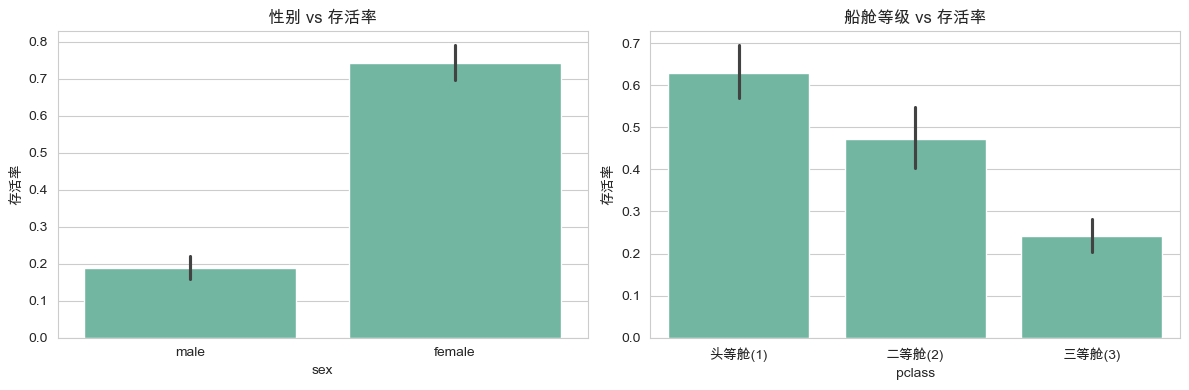

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图：性别 × 存活率
sns.barplot(data=df, x='sex', y='survived', ax=axes[0])
axes[0].set_title('性别 vs 存活率')
axes[0].set_ylabel('存活率')

# 右图：船舱等级 × 存活率
sns.barplot(data=df, x='pclass', y='survived', ax=axes[1])
axes[1].set_title('船舱等级 vs 存活率')
axes[1].set_ylabel('存活率')
axes[1].set_xticklabels(['头等舱(1)', '二等舱(2)', '三等舱(3)'])
plt.tight_layout()
plt.show()


### 下一段代码逐行拆解：年龄分布堆叠直方图

下面这行是这一节最复杂的一行，5 个参数全是新东西，提前拆开看。

```python
sns.histplot(data=df, x='age', hue='survived', multiple='stack', bins=30)
```

#### 5 个参数逐个看

| 参数 | 含义 | 这里的值 |
|---|---|---|
| `data=df` | 从哪个 DataFrame 取数据 | titanic 表 |
| `x='age'` | 横轴用哪一列（直方图的"分组依据"） | 年龄 |
| `hue='survived'` | **按哪一列分色** | 0/1 → 两种颜色 |
| `multiple='stack'` | 多组数据怎么排（叠加 / 并排 / 重叠） | `'stack'` = 上下堆叠 |
| `bins=30` | 横轴切成几段（"桶"） | 30 段 |

#### `histplot` 是干啥的

**hist**ogram + **plot** = **直方图**。它做一件事：

> 把连续数值（这里是年龄 0-80）**切成 N 段**，数每段里有多少人，画成柱子。

```
0-3   岁: ████ 14 人
3-6   岁: ████████ 22 人
...
30-33 岁: ████████████████ 56 人
...
```

#### `hue='survived'` 让每根柱子有"两种颜色"

`hue` 是 seaborn 里"按某列分色"的通用参数。`survived` 只有 0 和 1 两个值，所以会看到**两种颜色**：一种代表存活、一种代表没存活。

#### `multiple='stack'` —— 两种颜色怎么排

```
multiple='stack'  (堆叠)            multiple='dodge'  (并排)        multiple='fill'  (拉满100%)

30岁那一柱:                         30岁那一柱:                     30岁那一柱:
┌──────┐                            ┌──┐┌──┐                        ┌──────┐
│ 没活 │ ← 上                       │活││没│                        │ 没活 │ 80%
├──────┤                            │  ││活│                        ├──────┤
│  活  │ ← 下                       └──┘└──┘                        │  活  │ 20%
└──────┘                                                            └──────┘
柱高 = 总人数                       两根柱子并列                    每根都是 100%，只看比例
```

我们用 `stack` 是想**同时看到**「每个年龄段总人数」和「其中存活比例」。

#### `bins=30` —— 切成 30 段

年龄范围 0-80，分成 30 段，每段 ~3 岁宽。

- `bins=10` → 段太宽，看不出细节
- `bins=100` → 段太窄，每段人数少，图变毛刺
- `bins=30` → 经验值，一般刚好

---

### 跑完图怎么看

注释里说"**0-10 岁存活率高**"——这是从图哪里看出来的？

看最左边几根柱子（0-3 岁、3-6 岁、6-9 岁）：

- **存活颜色占整根柱子的比例明显比中间柱子大**
- 比如 0-3 岁那段：~14 人里 ~9 人活了下来（约 64%）
- 而 20-30 岁那段：~60 人里 ~12 人活下来（约 20%）

这印证了"**妇女儿童优先**"——疏散小孩时确实有优先权。

---

### 想直接看"比例"而不是"人数"？

把 `multiple='stack'` 改成 **`multiple='fill'`**：每根柱子都拉满 100%，**只看比例不看总数**。这样 0-10 岁存活占比的优势会更刺眼。

跑下面这段后，回头改一个字试试看：

```python
sns.histplot(data=df, x='age', hue='survived', multiple='fill', bins=30)
#                                              ↑ stack → fill
```

> Jupyter 的最大用处就是这种**"改一个参数 / 立刻看效果"**——比读 100 页文档管用。


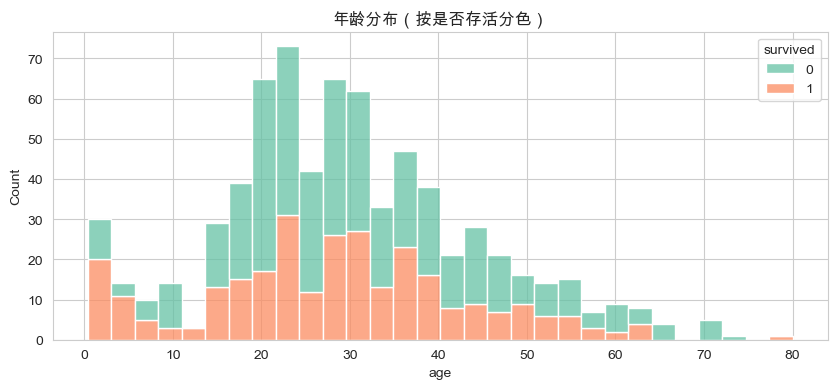

In [32]:
# 年龄分布（按存活与否分色叠加）
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='age', hue='survived', multiple='stack', bins=30)
plt.title('年龄分布（按是否存活分色）')
plt.show()
# → 注意看 0-10 岁这段，存活的比例明显比其他年龄段高


## 7. 特征工程

原始字段直接喂模型效果一般，**派生新特征**通常能显著提升模型表现：

- `family_size = sibsp + parch + 1`：家庭总人数（包括自己）
- `is_alone`：是否独自一人（0/1）

这一步在工业界叫"feature engineering"，是机器学习里非常重要的技能。


In [ ]:
# assign() 可以一次性新增多列，链式风格，比 df['new']=... 更优雅
df = df.assign(
    family_size = df['sibsp'] + df['parch'] + 1,
    is_alone = (df['sibsp'] + df['parch'] == 0).astype(int)
)
# df.head()
# 看一下家庭大小和存活率的关系
print('家庭大小 vs 存活率:')
print(df.groupby('family_size')['survived'].agg(['mean', 'count']).round(2))
print('\n→ 1人（独自）和 5+ 人（大家庭）的存活率都偏低')


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size,is_alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,1


## 8. 转 NumPy 准备喂模型

模型只认数字，所以：

1. **选数值列**（pclass, age, fare, family_size, is_alone）
2. **字符串列编码成数字**（这里把 sex 转成 0/1）
3. `.to_numpy()` 拿到 ndarray，shape `(N, features)`

这一步的产物 **X 和 y** 就是机器学习模型的标准输入。**你已经把"数据准备"这关打通了。**


### 代码逐行拆解

#### 整段代码

```python
# 性别字符串 → 数字（female=1, male=0）
df['sex_code'] = (df['sex'] == 'female').astype(int)

# 选特征
features = ['pclass', 'sex_code', 'age', 'fare', 'family_size', 'is_alone']
X = df[features].to_numpy()
y = df['survived'].to_numpy()

# 验证
print(f'X (特征矩阵): shape={X.shape}, dtype={X.dtype}')
print(f'y (标签): shape={y.shape}, dtype={y.dtype}')
print(X[:3])
print(y[:10])
print(f'存活比例: {y.mean():.1%}')
```

#### 第 1 行：字符串列编码成数字（最常用套路）

```python
df['sex_code'] = (df['sex'] == 'female').astype(int)
```

从里到外拆 3 步：

**① `df['sex'] == 'female'`** —— 对整列做布尔比较

```
sex 列        →    比较结果
'male'              False
'female'            True
'female'            True
'male'              False
```

> Pandas 的"**向量化操作**"：一个 `==` 对整列同时比较，不用 for 循环。和 NumPy broadcasting 一个套路。

**② `.astype(int)`** —— True/False → 1/0

```
True   → 1
False  → 0
```

**③ `df['sex_code'] = ...`** —— 把这列赋值给 DataFrame，新增列 `sex_code`

> **"`(s == value).astype(int)`" 是个万能模板**，所有"二元分类特征"都这么转：
> - 是否已婚: `(df['marital'] == 'married').astype(int)`
> - 是否高消费: `(df['income'] > 100000).astype(int)`

类别只有 2 个时（male/female），用 0/1 就够。≥ 3 个时（如 embarked 有 S/C/Q）要用 **one-hot 编码**——后面学 sklearn 时会处理。

#### 第 2-4 行：选特征、得到 X 和 y

```python
features = ['pclass', 'sex_code', 'age', 'fare', 'family_size', 'is_alone']
X = df[features].to_numpy()
y = df['survived'].to_numpy()
```

**为什么挑这 6 列**：

| 选 ✓ | 不选 ✗ |
|---|---|
| 数值列 | 字符串列（除非编码过）|
| 可能影响预测 | 完全无关的（如 PassengerId）|
| 缺失值已处理 | 还有 NaN 的列 |

> 这一步叫 **特征选择 (Feature Selection)**——ML 工程师 30% 的功夫花在这里。

**`.to_numpy()` 干了什么**：DataFrame → ndarray。**告别列名、只剩数字 + 形状**。

```
DataFrame 视图（有列名）              ndarray 视图（纯数字）
pclass sex_code age  fare ...        [[3, 0, 22.0, 7.25, ...],
3       0       22.0 7.25            [1, 1, 38.0, 71.28, ...],
1       1       38.0 71.28           [3, 1, 26.0, 7.92, ...],
3       1       26.0 7.92            ...]
```

ML 模型只需要后者。

#### X / y 命名约定（务必记住）

```
X  ── 大写 ── 矩阵 ── shape (N, features)  二维
y  ── 小写 ── 向量 ── shape (N,)           一维
```

**为什么 X 大写、y 小写**：数学约定——矩阵用大写、向量用小写。延续到代码里。

> **这两个变量名以后在 sklearn / PyTorch / 论文里你会看几千遍**，全世界 ML 圈雷打不动。

#### 第 5-9 行：打印验证

```
X (特征矩阵): shape=(891, 6), dtype=float64
y (标签): shape=(891,), dtype=int64
```

**关键观察**：

- `X` 是 `(891, 6)` —— 891 个样本、每个 6 个特征
- `y` 是 `(891,)` —— 891 个标签（尾巴的逗号是元组语法，见 `numpy轴的理解.md`）
- **第一个维度必须相等**——保证"X 的第 N 行对应 y 的第 N 个标签"

**dtype 解读**：

- `X` 是 `float64`：有小数（age=22.5、fare=7.25）
- `y` 是 `int64`：只有 0/1 整数

> 后面到 PyTorch 阶段会反复处理"dtype 不对"——模型要 float32 你给了 float64，要 long 你给了 int。**先在这里熟悉概念**。

**`X[:3]` 打印前 3 行**：

```
[[3.   0.   22.  7.25 2.   0.  ]      ← 第 0 个乘客
 [1.   1.   38. 71.28 2.   0.  ]      ← 第 1 个乘客
 [3.   1.   26.  7.92 1.   1.  ]]     ← 第 2 个乘客
```

**`y[:10]` 打印前 10 个标签**：

```
[0 1 1 1 0 0 0 0 1 1]
```

**第 0 行特征对应第 0 个标签 = 乘客 0 的完整信息**。这种"按行对齐"是 ML 数据的圣经。

**`y.mean()` 求存活率**：`y` 是 0/1 序列，求平均就 = 存活比例。

#### 这一步在 ML 全流程里的位置

```
原始数据         清洗               特征工程         ↓ 这里 ↓           模型训练
CSV/DB     →   df.fillna     →    df.assign    →   df.to_numpy()  →   model.fit(X, y)
(脏)           (干净 DataFrame)   (派生新特征)      (X, y 数组)         (神经网络/树/...)
```

**这一步是 "Pandas → 模型"** 的最后一道桥。过了：

- 离开 Pandas 世界（字符串、缺失值、列名）
- 进入 NumPy / PyTorch 世界（纯数字、shape、dtype）

你之前学的 axis / shape / broadcasting，**从这一步开始全部用得上**。

#### 一张图收尾

```
Pandas 世界                            NumPy / 模型世界
┌─────────────────────┐                ┌──────────────────┐
│ DataFrame (891 × N) │                │ X (891, 6)       │
│ ┌──────────────────┐│                │ ┌───────────────┐│
│ │ name  age sex ...││  .to_numpy()   │ │ 3  0  22  7.25││
│ │ Alice 25  F  ... ││  ──────────▶   │ │ 1  1  38 71.3 ││
│ │ Bob   30  M  ... ││                │ │ 3  1  26  7.92││
│ │ ...              ││                │ │ ...            ││
│ └──────────────────┘│                │ └───────────────┘│
│ + survived 列        │                │ y = [0,1,1,1,...]│
└─────────────────────┘                └──────────────────┘
   有标签、可读、灵活                     纯数字、规整、可算
```


In [ ]:
# 性别字符串 → 数字（female=1, male=0）
df['sex_code'] = (df['sex'] == 'female').astype(int)

# 选特征
features = ['pclass', 'sex_code', 'age', 'fare', 'family_size', 'is_alone']
X = df[features].to_numpy()
y = df['survived'].to_numpy()

print(f'X (特征矩阵): shape={X.shape}, dtype={X.dtype}')
print(f'y (标签): shape={y.shape}, dtype={y.dtype}')
print(f'\n前 3 行特征:')
print(X[:3])
print(f'\n前 10 个标签: {y[:10]}')
print(f'\n存活比例: {y.mean():.1%}')


## 总结：你刚才用过的核心 API

| API | 第几步用过 | 作用 |
|---|---|---|
| `sns.load_dataset` / `df.to_csv` | 1 | 加载/保存 |
| `df.head`, `info`, `describe`, `shape`, `dtypes` | 2 | 看数据 |
| `df.isna().sum().sort_values()` | 3 | 缺失统计 |
| `df.fillna`, `df.drop`, `series.median`, `series.mode` | 4 | 清洗 |
| `df.groupby('col')['target'].mean()` | 5 | 分组聚合 |
| `groupby([a, b]).mean().unstack()` | 5 | 交叉表 |
| `df.value_counts` | 5 | 频次统计 |
| `sns.barplot`, `histplot` | 6 | 可视化 |
| `df.assign`, `series.astype` | 7 | 派生特征 |
| `df.to_numpy` | 8 | 转 ndarray |

这就是 **NumPy/Pandas 速查表 ⭐⭐⭐ API** 在真实数据上的使用场景。你已经把它们都见过一遍——后面遇到它们不会再陌生。

## 下一步可以做的延伸（可选）

1. **更多特征工程**：从 `name` 字段提取头衔（Mr./Mrs./Miss./Master）
2. **更多分析角度**：看 `fare`（票价）和存活的关系
3. **跑第一个模型**：进入阶段 05 时，把上面的 X, y 喂给 `sklearn.linear_model.LogisticRegression`，看准确率
4. **写到笔记里**：你看下来对哪个 API 最不熟，回到 [`pandas理解.md`](../../notes/pandas理解.md) 复习

**有任何看不懂的 cell，标记 cell 序号问 Claude，会一对一解释。**
